# predic_consumo_agua_v9

Experimento complementario para responder la observacion metodologica sobre correlaciones bajas de Pearson, posibles asociaciones monotonicas, dependencias no lineales, rezagos climaticos y comparacion formal entre modelos lineales y XGBoost bajo validacion temporal.

Este notebook no modifica los notebooks `predic_consumo_agua.ipynb` ni las versiones `v2` a `v8`. Todas las decisiones que pueden afectar seleccion de variables, rezagos, hiperparametros o modelos se realizan sin consultar 2024.


## 1. Criterio metodologico

Se recupera la base final `df_consumo_bime_clima_v3.xlsx` con 596 registros y unidad localidad-ano-bimestre. La variable objetivo es `consumo_promedio`. Se conservan las 24 variables predictoras usadas en v7-v8 cuando se incluyen coordenadas y las 22 variables obtenidas al excluir `latitud` y `longitud`. Las columnas `metros_cubicos`, `facturas`, `suscriptores_facturados` y `suscriptores_con_medidor` se eliminan por posible fuga de informacion. Tambien se aplica la misma depuracion de variables climaticas redundantes usada en v7-v8.

El analisis se divide en cuatro componentes: correlaciones contemporaneas de Pearson y Spearman, informacion mutua, correlaciones climaticas con rezagos exactos de uno a tres bimestres, y comparacion temporal entre regresion lineal multiple, Ridge y XGBoost. La transformacion `log1p` se usa durante el entrenamiento de los modelos y las metricas se calculan en la escala original mediante `expm1`.

Sumapaz no se excluye de los analisis principales de v9 porque el experimento temporal de v8 fue realizado con todas las localidades. La exclusion de Sumapaz se mantiene como sensibilidad espacial especifica de LOLO en v6, no como filtro general de los experimentos temporales.


## 2. Librerias y configuracion


In [1]:
import json
import hashlib
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

import scipy
from scipy import stats

import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression

import xgboost
from xgboost import XGBRegressor

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

print("Version pandas:", pd.__version__)
print("Version numpy:", np.__version__)
print("Version scipy:", scipy.__version__)
print("Version scikit-learn:", sklearn.__version__)
print("Version XGBoost:", xgboost.__version__)


Version pandas: 2.3.3
Version numpy: 2.2.6
Version scipy: 1.15.3
Version scikit-learn: 1.7.2
Version XGBoost: 2.1.4


## 3. Carga de datos y funciones comunes


In [2]:
DATA_PATH = Path("df_consumo_bime_clima_v3.xlsx")
TARGET = "consumo_promedio"
RANDOM_STATE = 42

LEAKAGE_COLUMNS = [
    "metros_cubicos",
    "facturas",
    "suscriptores_facturados",
    "suscriptores_con_medidor",
]

REDUNDANT_OR_DERIVED_COLUMNS = [
    "T2MWET", "T2MDEW", "T2M_RANGE",
    "WS10M_MAX", "WS10M_MIN", "WS10M_RANGE",
    "WS2M_MAX", "WS2M_MIN", "WS2M_RANGE",
    "WD10M", "WD2M",
    "ALLSKY_SFC_PAR_TOT", "CLRSKY_SFC_PAR_TOT",
    "ALLSKY_SFC_SW_DIFF", "ALLSKY_SFC_SW_DNI",
    "ALLSKY_SFC_UVA", "ALLSKY_SFC_UVB", "ALLSKY_SFC_UV_INDEX",
    "CLRSKY_SFC_SW_DWN", "TOA_SW_DWN",
]

# Hiperparametros temporales seleccionados en v8 usando validacion 2023.
XGB_TEMPORAL_PARAMS_WITH_SPATIAL = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

XGB_TEMPORAL_PARAMS_WITHOUT_SPATIAL = {
    "n_estimators": 200,
    "learning_rate": 0.03,
    "max_depth": 4,
    "min_child_weight": 1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

RIDGE_ALPHA_GRID = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

df_raw = pd.read_excel(DATA_PATH)
YEAR_COL = next(c for c in df_raw.columns if c.encode("unicode_escape").decode("ascii") == "a\\xf1o")
BIMESTER_COL = "BIMESTRE"
LOCALITY_COL = "localidad"

df_raw = df_raw.copy()
df_raw["_row_id"] = np.arange(len(df_raw))
df_raw[YEAR_COL] = pd.to_numeric(df_raw[YEAR_COL], errors="coerce")
df_raw[BIMESTER_COL] = pd.to_numeric(df_raw[BIMESTER_COL], errors="coerce")
df_raw["indice_tiempo"] = (df_raw[YEAR_COL] - 2020) * 6 + (df_raw[BIMESTER_COL] - 1)
df_raw = df_raw.sort_values([YEAR_COL, BIMESTER_COL, LOCALITY_COL]).reset_index(drop=True)

print("Dataset:", DATA_PATH)
print("Dimensiones:", df_raw.shape)
print("Columna ano:", YEAR_COL)
print("Duplicados localidad-ano-bimestre:", int(df_raw.duplicated([LOCALITY_COL, YEAR_COL, BIMESTER_COL]).sum()))
display(df_raw.groupby(YEAR_COL).size().rename("n_registros").reset_index())
display(df_raw.groupby([YEAR_COL, BIMESTER_COL]).size().rename("n_registros").reset_index().head(12))


Dataset: df_consumo_bime_clima_v3.xlsx
Dimensiones: (596, 51)
Columna ano: año
Duplicados localidad-ano-bimestre: 0


,año,n_registros
0,2020,120
1,2021,120
2,2022,119
3,2023,120
4,2024,117


,año,BIMESTRE,n_registros
0,2020,1,20
1,2020,2,20
2,2020,3,20
3,2020,4,20
4,2020,5,20
5,2020,6,20
6,2021,1,20
7,2021,2,20
8,2021,3,20
9,2021,4,20


In [3]:
def benjamini_hochberg(pvalues):
    p = np.asarray(pvalues, dtype=float)
    adjusted = np.full(p.shape, np.nan, dtype=float)
    valid = np.isfinite(p)
    if valid.sum() == 0:
        return adjusted
    p_valid = p[valid]
    order = np.argsort(p_valid)
    ranked = p_valid[order]
    n = len(ranked)
    adj_sorted = ranked * n / np.arange(1, n + 1)
    adj_sorted = np.minimum.accumulate(adj_sorted[::-1])[::-1]
    adj_sorted = np.clip(adj_sorted, 0, 1)
    adj_valid = np.empty(n)
    adj_valid[order] = adj_sorted
    adjusted[valid] = adj_valid
    return adjusted


def classify_abs_correlation(value):
    if pd.isna(value):
        return "no calculable"
    av = abs(value)
    if av < 0.10:
        return "muy debil"
    if av < 0.30:
        return "debil"
    if av < 0.50:
        return "moderada"
    return "alta"


def safe_corr(x, y, method):
    pair = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(pair) < 3 or pair["x"].nunique() < 2 or pair["y"].nunique() < 2:
        return np.nan, np.nan, len(pair)
    if method == "pearson":
        coef, pvalue = stats.pearsonr(pair["x"], pair["y"])
    elif method == "spearman":
        coef, pvalue = stats.spearmanr(pair["x"], pair["y"])
    else:
        raise ValueError(method)
    return float(coef), float(pvalue), len(pair)


def metrics_original_scale(y_true_log, y_pred_log):
    y_true = np.expm1(np.asarray(y_true_log, dtype=float))
    y_pred = np.expm1(np.asarray(y_pred_log, dtype=float))
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def build_design_matrix(raw_df, include_spatial=True, extra_lag_features=None, common_complete_lag_mask=False):
    data = raw_df.copy()
    data = data[data[TARGET].notna()].copy()
    y_original = pd.to_numeric(data[TARGET], errors="coerce")
    valid_y = y_original.notna()
    data = data.loc[valid_y].copy()
    y_original = y_original.loc[valid_y]
    if (y_original < 0).any():
        raise ValueError("No se puede aplicar log1p porque existen valores negativos en el target.")

    metadata = data[["_row_id", LOCALITY_COL, YEAR_COL, BIMESTER_COL, "indice_tiempo"]].copy()
    drop_cols = [c for c in LEAKAGE_COLUMNS + REDUNDANT_OR_DERIVED_COLUMNS if c in data.columns]
    drop_cols += [TARGET, LOCALITY_COL, "_row_id", "indice_tiempo"]
    if not include_spatial:
        drop_cols += [c for c in ["latitud", "longitud"] if c in data.columns]
    drop_cols = list(dict.fromkeys([c for c in drop_cols if c in data.columns]))

    X = data.drop(columns=drop_cols).copy()
    if BIMESTER_COL in X.columns:
        X[BIMESTER_COL] = pd.to_numeric(X[BIMESTER_COL], errors="coerce")
        X["BIMESTRE_sin"] = np.sin(2 * np.pi * X[BIMESTER_COL] / 6)
        X["BIMESTRE_cos"] = np.cos(2 * np.pi * X[BIMESTER_COL] / 6)
        X = X.drop(columns=[BIMESTER_COL])

    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    if extra_lag_features is not None and not extra_lag_features.empty:
        lag_cols = [c for c in extra_lag_features.columns if c.startswith("lag_")]
        extra = extra_lag_features[["_row_id"] + lag_cols].copy()
        X = X.merge(extra, left_on=metadata["_row_id"], right_on="_row_id", how="left").drop(columns=["_row_id"])
        if common_complete_lag_mask and lag_cols:
            complete_mask = X[lag_cols].notna().all(axis=1)
            X = X.loc[complete_mask].reset_index(drop=True)
            y_original = y_original.reset_index(drop=True).loc[complete_mask].reset_index(drop=True)
            metadata = metadata.reset_index(drop=True).loc[complete_mask].reset_index(drop=True)
        else:
            X = X.reset_index(drop=True)
            y_original = y_original.reset_index(drop=True)
            metadata = metadata.reset_index(drop=True)
    else:
        X = X.reset_index(drop=True)
        y_original = y_original.reset_index(drop=True)
        metadata = metadata.reset_index(drop=True)

    return X, np.log1p(y_original).reset_index(drop=True), y_original.reset_index(drop=True), metadata.reset_index(drop=True), drop_cols


def impute_fit_train(X_train, *splits):
    imputer = SimpleImputer(strategy="median")
    X_train_i = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    outputs = [X_train_i]
    for split in splits:
        outputs.append(pd.DataFrame(imputer.transform(split), columns=X_train.columns, index=split.index))
    return outputs, imputer


def year_label(values):
    years = sorted(set(int(v) for v in values))
    if len(years) > 1 and years == list(range(min(years), max(years) + 1)):
        return f"{min(years)}-{max(years)}"
    return ",".join(str(y) for y in years)


## 4. Matriz de predictores recuperada de v7-v8


In [4]:
X_all_spatial, y_log_all, y_original_all, meta_all, dropped_columns = build_design_matrix(df_raw, include_spatial=True)
X_all_no_spatial, _, _, _, _ = build_design_matrix(df_raw, include_spatial=False)

climate_columns = [
    c for c in X_all_spatial.columns
    if c not in [YEAR_COL, "latitud", "longitud", "BIMESTRE_sin", "BIMESTRE_cos"]
]

print("Columnas excluidas:")
for col in dropped_columns:
    print(" -", col)
print("\nVariables con coordenadas:", X_all_spatial.shape[1])
print(X_all_spatial.columns.tolist())
print("\nVariables sin coordenadas:", X_all_no_spatial.shape[1])
print(X_all_no_spatial.columns.tolist())
print("\nVariables climaticas consideradas para rezagos:", len(climate_columns))
print(climate_columns)

assert X_all_spatial.shape == (596, 24)
assert X_all_no_spatial.shape == (596, 22)
assert TARGET == "consumo_promedio"


Columnas excluidas:
 - metros_cubicos
 - facturas
 - suscriptores_facturados
 - suscriptores_con_medidor
 - T2MWET
 - T2MDEW
 - T2M_RANGE
 - WS10M_MAX
 - WS10M_MIN
 - WS10M_RANGE
 - WS2M_MAX
 - WS2M_MIN
 - WS2M_RANGE
 - WD10M
 - WD2M
 - ALLSKY_SFC_PAR_TOT
 - CLRSKY_SFC_PAR_TOT
 - ALLSKY_SFC_SW_DIFF
 - ALLSKY_SFC_SW_DNI
 - ALLSKY_SFC_UVA
 - ALLSKY_SFC_UVB
 - ALLSKY_SFC_UV_INDEX
 - CLRSKY_SFC_SW_DWN
 - TOA_SW_DWN
 - consumo_promedio
 - localidad
 - _row_id
 - indice_tiempo

Variables con coordenadas: 24
['año', 'latitud', 'longitud', 'ALLSKY_SFC_LW_DWN', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SRF_ALB', 'CLOUD_AMT', 'GWETPROF', 'GWETROOT', 'GWETTOP', 'ONI', 'PRECTOTCORR', 'PRECTOTCORR_SUM', 'PS', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'TS', 'WS10M', 'WS2M', 'BIMESTRE_sin', 'BIMESTRE_cos']

Variables sin coordenadas: 22
['año', 'ALLSKY_SFC_LW_DWN', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SRF_ALB', 'CLOUD_AMT', 'GWETPROF', 'GWETROOT', 'GWETTOP', 'ONI', 'PRECTOTCORR', 'PRECTOTCORR_SUM', 'PS', 'QV2M', 'RH2M

## 5. Correlaciones contemporaneas Pearson y Spearman


Top 12 por |Spearman| con 596 registros:


,analisis,variable,n_observaciones,pearson,p_pearson,spearman,p_spearman,p_pearson_ajustado_bh,p_spearman_ajustado_bh,diferencia_abs_spearman_pearson,signo_pearson,signo_spearman,coincide_sentido,spearman_supera_pearson,magnitud_spearman
0,todos_596_registros,BIMESTRE_sin,596,0.129914,1.480725e-03,0.167423,0.000040,8.884351e-03,0.000959,0.037509,positivo,positivo,True,False,debil
1,todos_596_registros,latitud,596,-0.415220,3.052367e-26,-0.101701,0.012989,7.325681e-25,0.155864,0.313519,negativo,negativo,True,False,debil
2,todos_596_registros,PRECTOTCORR,596,0.050326,2.198966e-01,0.070690,0.084656,5.277519e-01,0.372166,0.020364,positivo,positivo,True,False,muy debil
3,todos_596_registros,PS,596,-0.146224,3.415657e-04,-0.068680,0.093903,2.732526e-03,0.372166,0.077543,negativo,negativo,True,False,muy debil
4,todos_596_registros,año,596,-0.069216,9.136434e-02,-0.067658,0.098909,3.538985e-01,0.372166,0.001557,negativo,negativo,True,False,muy debil
5,todos_596_registros,longitud,596,-0.171774,2.485579e-05,0.066070,0.107104,2.982694e-04,0.372166,0.105704,negativo,positivo,False,False,muy debil
6,todos_596_registros,PRECTOTCORR_SUM,596,0.047713,2.448157e-01,0.065800,0.108548,5.341432e-01,0.372166,0.018087,positivo,positivo,True,False,muy debil
7,todos_596_registros,T2M,596,-0.066810,1.032204e-01,-0.052677,0.199068,3.538985e-01,0.597204,0.014133,negativo,negativo,True,False,muy debil
8,todos_596_registros,T2M_MAX,596,-0.067912,9.764405e-02,-0.046932,0.252631,3.538985e-01,0.642558,0.020980,negativo,negativo,True,False,muy debil
9,todos_596_registros,TS,596,-0.060429,1.406165e-01,-0.043687,0.286966,4.218494e-01,0.642558,0.016742,negativo,negativo,True,False,muy debil


Top 12 por |Spearman| en sensibilidad 2020-2023:


,analisis,variable,n_observaciones,pearson,p_pearson,spearman,p_spearman,p_pearson_ajustado_bh,p_spearman_ajustado_bh,diferencia_abs_spearman_pearson,signo_pearson,signo_spearman,coincide_sentido,spearman_supera_pearson,magnitud_spearman
0,sensibilidad_2020_2023_sin_2024,latitud,479,-0.397550,1.379168e-19,-0.107800,0.018273,3.310002e-18,0.195183,0.289750,negativo,negativo,True,False,debil
1,sensibilidad_2020_2023_sin_2024,CLOUD_AMT,479,-0.042625,3.519188e-01,-0.104394,0.022310,7.038376e-01,0.195183,0.061769,negativo,negativo,True,False,debil
2,sensibilidad_2020_2023_sin_2024,BIMESTRE_sin,479,0.099661,2.918945e-02,0.102838,0.024398,1.751367e-01,0.195183,0.003177,positivo,positivo,True,False,debil
3,sensibilidad_2020_2023_sin_2024,PRECTOTCORR,479,0.054670,2.323672e-01,0.090964,0.046617,6.100396e-01,0.211041,0.036293,positivo,positivo,True,False,muy debil
4,sensibilidad_2020_2023_sin_2024,PRECTOTCORR_SUM,479,0.052200,2.541832e-01,0.089221,0.051000,6.100396e-01,0.211041,0.037021,positivo,positivo,True,False,muy debil
5,sensibilidad_2020_2023_sin_2024,ALLSKY_SFC_LW_DWN,479,0.015614,7.332066e-01,0.087446,0.055810,8.433384e-01,0.211041,0.071832,positivo,positivo,True,False,muy debil
6,sensibilidad_2020_2023_sin_2024,longitud,479,-0.170204,1.820482e-04,0.085486,0.061554,2.184579e-03,0.211041,0.084718,negativo,positivo,False,False,muy debil
7,sensibilidad_2020_2023_sin_2024,ALLSKY_SRF_ALB,479,-0.036445,4.261438e-01,-0.079428,0.082465,7.131781e-01,0.247394,0.042983,negativo,negativo,True,False,muy debil
8,sensibilidad_2020_2023_sin_2024,QV2M,479,-0.003210,9.441409e-01,0.075112,0.100605,9.441409e-01,0.268281,0.071902,negativo,positivo,False,False,muy debil
9,sensibilidad_2020_2023_sin_2024,año,479,-0.011061,8.091995e-01,0.054276,0.235757,8.827630e-01,0.565817,0.043215,negativo,positivo,False,False,muy debil


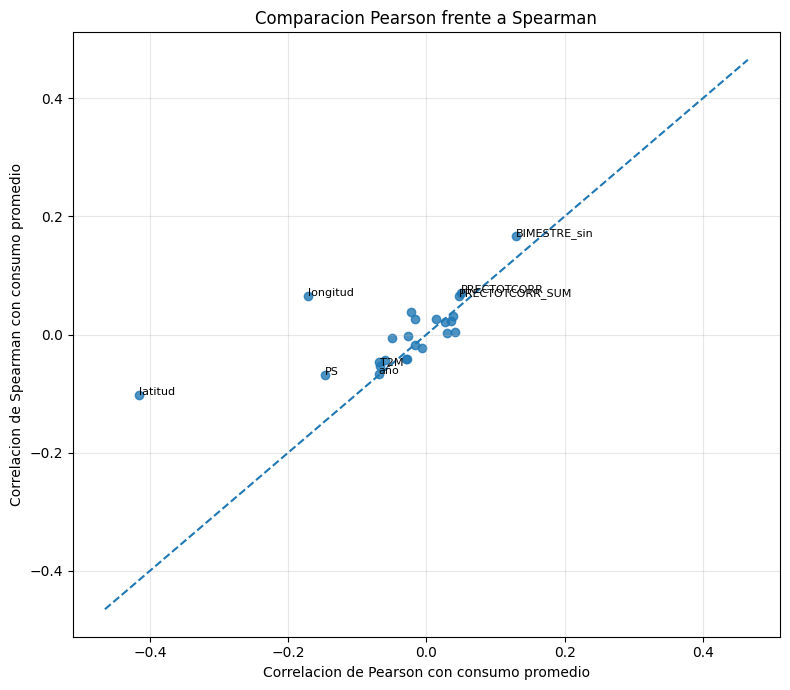

In [5]:
def contemporary_correlations(X, y_original, meta, analysis_name, year_mask=None):
    if year_mask is None:
        mask = pd.Series(True, index=meta.index)
    else:
        mask = year_mask.reset_index(drop=True)
    rows = []
    for variable in X.columns:
        x = X.loc[mask, variable]
        y = y_original.loc[mask]
        pearson, p_pearson, n_p = safe_corr(x, y, "pearson")
        spearman, p_spearman, n_s = safe_corr(x, y, "spearman")
        rows.append({
            "analisis": analysis_name,
            "variable": variable,
            "n_observaciones": min(n_p, n_s),
            "pearson": pearson,
            "p_pearson": p_pearson,
            "spearman": spearman,
            "p_spearman": p_spearman,
        })
    out = pd.DataFrame(rows)
    out["p_pearson_ajustado_bh"] = benjamini_hochberg(out["p_pearson"])
    out["p_spearman_ajustado_bh"] = benjamini_hochberg(out["p_spearman"])
    out["diferencia_abs_spearman_pearson"] = (out["spearman"].abs() - out["pearson"].abs()).abs()
    out["signo_pearson"] = np.sign(out["pearson"]).map({-1.0: "negativo", 0.0: "cero", 1.0: "positivo"})
    out["signo_spearman"] = np.sign(out["spearman"]).map({-1.0: "negativo", 0.0: "cero", 1.0: "positivo"})
    out["coincide_sentido"] = out["signo_pearson"].eq(out["signo_spearman"])
    out["spearman_supera_pearson"] = out["spearman"].abs() >= (out["pearson"].abs() + 0.10)
    out["magnitud_spearman"] = out["spearman"].map(classify_abs_correlation)
    return out.sort_values("spearman", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)


corr_all = contemporary_correlations(
    X_all_spatial, y_original_all, meta_all, "todos_596_registros"
)
mask_2020_2023 = meta_all[YEAR_COL].between(2020, 2023).reset_index(drop=True)
corr_2020_2023 = contemporary_correlations(
    X_all_spatial, y_original_all, meta_all, "sensibilidad_2020_2023_sin_2024", mask_2020_2023
)

correlaciones_pearson_spearman = pd.concat([corr_all, corr_2020_2023], ignore_index=True)
correlaciones_pearson_spearman.to_csv("correlaciones_pearson_spearman_v9.csv", index=False, encoding="utf-8-sig")

print("Top 12 por |Spearman| con 596 registros:")
display(corr_all.head(12))
print("Top 12 por |Spearman| en sensibilidad 2020-2023:")
display(corr_2020_2023.head(12))

plt.figure(figsize=(8, 7))
plt.scatter(corr_all["pearson"], corr_all["spearman"], alpha=0.8)
for _, row in corr_all.head(8).iterrows():
    plt.annotate(row["variable"], (row["pearson"], row["spearman"]), fontsize=8)
lim = max(corr_all[["pearson", "spearman"]].abs().max()) + 0.05
plt.plot([-lim, lim], [-lim, lim], linestyle="--")
plt.xlabel("Correlacion de Pearson con consumo promedio")
plt.ylabel("Correlacion de Spearman con consumo promedio")
plt.title("Comparacion Pearson frente a Spearman")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Informacion mutua en 2020-2023


,variable,informacion_mutua_media,informacion_mutua_std,ranking_mi,pearson,spearman,ranking_abs_pearson,ranking_abs_spearman,diferencia_ranking_mi_spearman,parametros
0,longitud,1.407517,0.081628,1,-0.170204,0.085486,2,7,-6,"mutual_info_regression, n_neighbors=3, bootstr..."
1,latitud,1.345521,0.078089,2,-0.397550,-0.107800,1,1,1,"mutual_info_regression, n_neighbors=3, bootstr..."
2,PS,0.637204,0.074075,3,-0.135820,-0.042232,3,11,-8,"mutual_info_regression, n_neighbors=3, bootstr..."
3,T2M,0.588664,0.090983,4,-0.059166,-0.024298,6,19,-15,"mutual_info_regression, n_neighbors=3, bootstr..."
4,TS,0.587502,0.081824,5,-0.058011,-0.039015,7,13,-8,"mutual_info_regression, n_neighbors=3, bootstr..."
5,T2M_MAX,0.585703,0.086351,6,-0.068211,-0.037994,5,14,-8,"mutual_info_regression, n_neighbors=3, bootstr..."
6,RH2M,0.564531,0.096487,7,0.039792,0.035417,13,17,-10,"mutual_info_regression, n_neighbors=3, bootstr..."
7,T2M_MIN,0.562366,0.085023,8,-0.054033,-0.018837,9,21,-13,"mutual_info_regression, n_neighbors=3, bootstr..."
8,QV2M,0.540384,0.094595,9,-0.003210,0.075112,24,9,0,"mutual_info_regression, n_neighbors=3, bootstr..."
9,GWETTOP,0.535811,0.081586,10,0.044568,0.041174,11,12,-2,"mutual_info_regression, n_neighbors=3, bootstr..."


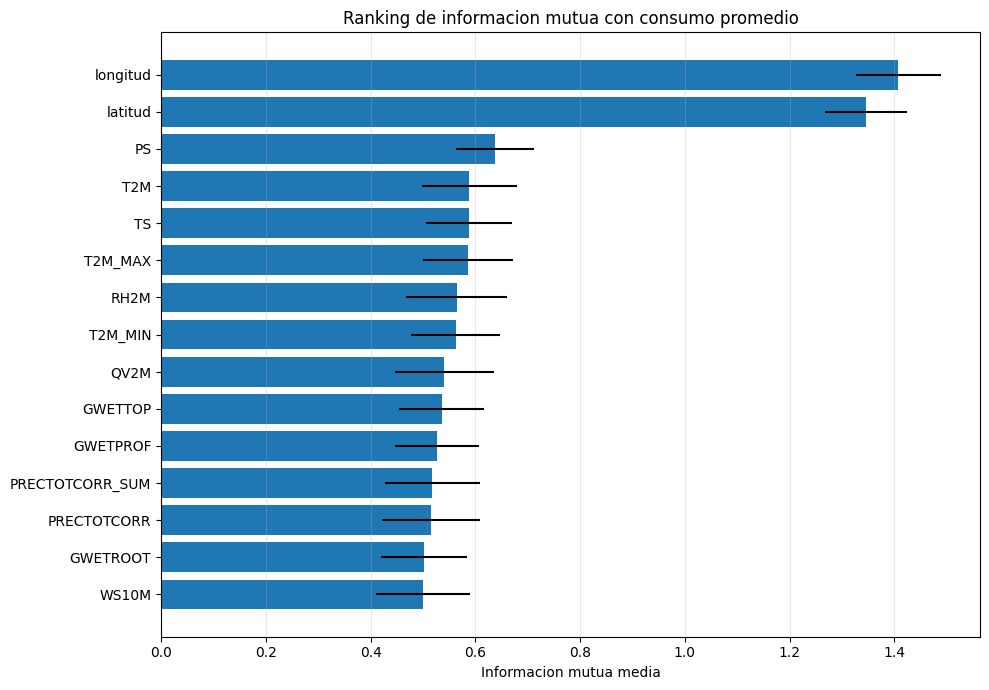

In [6]:
X_mi = X_all_spatial.loc[mask_2020_2023].reset_index(drop=True)
y_mi = y_original_all.loc[mask_2020_2023].reset_index(drop=True)

imputer_mi = SimpleImputer(strategy="median")
X_mi_imp = pd.DataFrame(imputer_mi.fit_transform(X_mi), columns=X_mi.columns)

rng = np.random.default_rng(RANDOM_STATE)
n_bootstrap = 50
mi_values = []
for b in range(n_bootstrap):
    sample_idx = rng.integers(0, len(X_mi_imp), size=len(X_mi_imp))
    mi = mutual_info_regression(
        X_mi_imp.iloc[sample_idx],
        y_mi.iloc[sample_idx],
        random_state=RANDOM_STATE + b,
        n_neighbors=3,
    )
    mi_values.append(mi)

mi_array = np.vstack(mi_values)
mi_df = pd.DataFrame({
    "variable": X_mi_imp.columns,
    "informacion_mutua_media": mi_array.mean(axis=0),
    "informacion_mutua_std": mi_array.std(axis=0, ddof=1),
}).sort_values("informacion_mutua_media", ascending=False).reset_index(drop=True)
mi_df["ranking_mi"] = np.arange(1, len(mi_df) + 1)

corr_ref = corr_2020_2023[["variable", "pearson", "spearman"]].copy()
corr_ref["ranking_abs_pearson"] = corr_ref["pearson"].abs().rank(ascending=False, method="min").astype(int)
corr_ref["ranking_abs_spearman"] = corr_ref["spearman"].abs().rank(ascending=False, method="min").astype(int)

informacion_mutua = mi_df.merge(corr_ref, on="variable", how="left")
informacion_mutua["diferencia_ranking_mi_spearman"] = informacion_mutua["ranking_mi"] - informacion_mutua["ranking_abs_spearman"]
informacion_mutua["parametros"] = "mutual_info_regression, n_neighbors=3, bootstrap=50, random_state=42, imputacion mediana ajustada con 2020-2023"
informacion_mutua.to_csv("informacion_mutua_v9.csv", index=False, encoding="utf-8-sig")

display(informacion_mutua.head(15))

top_mi = informacion_mutua.head(15).sort_values("informacion_mutua_media", ascending=True)
plt.figure(figsize=(10, 7))
plt.barh(top_mi["variable"], top_mi["informacion_mutua_media"], xerr=top_mi["informacion_mutua_std"])
plt.xlabel("Informacion mutua media")
plt.title("Ranking de informacion mutua con consumo promedio")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Construccion exacta de rezagos climaticos


In [7]:
def create_exact_lag_table(raw_df, climate_cols, lags=(1, 2, 3)):
    base = raw_df[["_row_id", LOCALITY_COL, YEAR_COL, BIMESTER_COL, "indice_tiempo", TARGET] + climate_cols].copy()
    rows = []
    lag_feature_frames = [raw_df[["_row_id"]].copy()]

    for lag in lags:
        lag_source = base[[LOCALITY_COL, "indice_tiempo"] + climate_cols].copy()
        lag_source["indice_tiempo_objetivo"] = lag_source["indice_tiempo"] + lag
        rename_map = {c: f"lag_{lag}_{c}" for c in climate_cols}
        lag_source = lag_source.rename(columns=rename_map)
        lag_source = lag_source.rename(columns={"indice_tiempo": f"indice_tiempo_origen_lag_{lag}"})

        target_rows = base[["_row_id", LOCALITY_COL, YEAR_COL, BIMESTER_COL, "indice_tiempo", TARGET]].copy()
        merged = target_rows.merge(
            lag_source,
            left_on=[LOCALITY_COL, "indice_tiempo"],
            right_on=[LOCALITY_COL, "indice_tiempo_objetivo"],
            how="left",
            validate="one_to_one",
        )

        valid_source = merged[f"indice_tiempo_origen_lag_{lag}"].notna()
        assert ((merged.loc[valid_source, "indice_tiempo"] - merged.loc[valid_source, f"indice_tiempo_origen_lag_{lag}"]) == lag).all()
        assert (merged.loc[valid_source, f"indice_tiempo_origen_lag_{lag}"] < merged.loc[valid_source, "indice_tiempo"]).all()

        lag_cols = [f"lag_{lag}_{c}" for c in climate_cols]
        lag_feature_frames.append(merged[["_row_id"] + lag_cols])

        for c in climate_cols:
            lag_col = f"lag_{lag}_{c}"
            pearson, p_pearson, n_p = safe_corr(merged[lag_col], merged[TARGET], "pearson")
            spearman, p_spearman, n_s = safe_corr(merged[lag_col], merged[TARGET], "spearman")
            rows.append({
                "variable": c,
                "rezago_bimestres": lag,
                "n_pares_validos": min(n_p, n_s),
                "pearson": pearson,
                "p_pearson": p_pearson,
                "spearman": spearman,
                "p_spearman": p_spearman,
            })

    lag_features = lag_feature_frames[0]
    for frame in lag_feature_frames[1:]:
        lag_features = lag_features.merge(frame, on="_row_id", how="left", validate="one_to_one")

    lag_corr = pd.DataFrame(rows)
    lag_corr["p_pearson_ajustado_bh"] = benjamini_hochberg(lag_corr["p_pearson"])
    lag_corr["p_spearman_ajustado_bh"] = benjamini_hochberg(lag_corr["p_spearman"])
    return lag_corr, lag_features


correlaciones_rezagos, lag_features_all = create_exact_lag_table(df_raw, climate_columns, lags=(1, 2, 3))

contemporary_climate = corr_all[corr_all["variable"].isin(climate_columns)][
    ["variable", "pearson", "spearman", "p_pearson_ajustado_bh", "p_spearman_ajustado_bh"]
].rename(columns={
    "pearson": "pearson_contemporaneo",
    "spearman": "spearman_contemporaneo",
    "p_pearson_ajustado_bh": "p_pearson_contemporaneo_ajustado_bh",
    "p_spearman_ajustado_bh": "p_spearman_contemporaneo_ajustado_bh",
})
correlaciones_rezagos = correlaciones_rezagos.merge(contemporary_climate, on="variable", how="left")
correlaciones_rezagos["cambio_abs_pearson_vs_contemporaneo"] = correlaciones_rezagos["pearson"].abs() - correlaciones_rezagos["pearson_contemporaneo"].abs()
correlaciones_rezagos["cambio_abs_spearman_vs_contemporaneo"] = correlaciones_rezagos["spearman"].abs() - correlaciones_rezagos["spearman_contemporaneo"].abs()
correlaciones_rezagos["direccion_spearman"] = np.sign(correlaciones_rezagos["spearman"]).map({-1.0: "negativa", 0.0: "cero", 1.0: "positiva"})
correlaciones_rezagos["magnitud_spearman"] = correlaciones_rezagos["spearman"].map(classify_abs_correlation)
correlaciones_rezagos.to_csv("correlaciones_rezagos_v9.csv", index=False, encoding="utf-8-sig")

resumen_rezagos = (
    correlaciones_rezagos
    .sort_values(["variable", "spearman"], key=lambda s: s.abs() if s.name == "spearman" else s, ascending=[True, False])
    .groupby("variable", as_index=False)
    .first()
)
resumen_rezagos = resumen_rezagos.rename(columns={
    "rezago_bimestres": "rezago_mayor_abs_spearman",
    "spearman": "spearman_rezago_mayor",
    "pearson": "pearson_mismo_rezago",
})
resumen_rezagos.to_csv("resumen_rezagos_v9.csv", index=False, encoding="utf-8-sig")

print("Primeras correlaciones rezagadas por |Spearman|:")
display(correlaciones_rezagos.sort_values("spearman", key=lambda s: s.abs(), ascending=False).head(20))
print("Resumen por variable climatica:")
display(resumen_rezagos)

assert lag_features_all.shape[0] == df_raw.shape[0]
print("Verificaciones de rezagos exactos superadas: misma localidad por merge, diferencia temporal exacta, sin informacion futura y sin interpolacion.")


Primeras correlaciones rezagadas por |Spearman|:


,variable,rezago_bimestres,n_pares_validos,pearson,p_pearson,spearman,p_spearman,p_pearson_ajustado_bh,p_spearman_ajustado_bh,pearson_contemporaneo,spearman_contemporaneo,p_pearson_contemporaneo_ajustado_bh,p_spearman_contemporaneo_ajustado_bh,cambio_abs_pearson_vs_contemporaneo,cambio_abs_spearman_vs_contemporaneo,direccion_spearman,magnitud_spearman
51,T2M,3,535,-0.127094,0.003232,-0.150415,0.000481,0.018422,0.009780,-0.066810,-0.052677,0.353899,0.597204,0.060284,0.097738,negativa,debil
30,QV2M,2,555,-0.156146,0.000222,-0.147005,0.000512,0.003159,0.009780,-0.021681,0.038364,0.716792,0.645806,0.134465,0.108642,negativa,debil
40,ALLSKY_SRF_ALB,3,535,0.109383,0.011350,0.146330,0.000686,0.046213,0.009780,-0.005778,-0.023438,0.888051,0.754478,0.103605,0.122892,positiva,debil
10,PS,1,575,-0.140654,0.000719,-0.142113,0.000632,0.006830,0.009780,-0.146224,-0.068680,0.002733,0.372166,-0.005570,0.073432,negativa,debil
54,TS,3,535,-0.124747,0.003853,-0.134447,0.001829,0.019966,0.018241,-0.060429,-0.043687,0.421849,0.642558,0.064318,0.090760,negativa,debil
52,T2M_MAX,3,535,-0.130644,0.002464,-0.133834,0.001920,0.015606,0.018241,-0.067912,-0.046932,0.353899,0.642558,0.062731,0.086902,negativa,debil
29,PS,2,555,-0.134098,0.001544,-0.111098,0.008805,0.010999,0.071701,-0.146224,-0.068680,0.002733,0.372166,-0.012125,0.042418,negativa,debil
20,ALLSKY_SFC_SW_DWN,2,555,0.069819,0.100356,0.106498,0.012059,0.228813,0.085919,-0.028956,-0.041180,0.665174,0.642558,0.040863,0.065318,positiva,debil
49,QV2M,3,535,-0.122895,0.004417,-0.105787,0.014365,0.020981,0.089440,-0.021681,0.038364,0.716792,0.645806,0.101215,0.067423,negativa,debil
38,ALLSKY_SFC_LW_DWN,3,535,-0.114421,0.008071,-0.104412,0.015691,0.035389,0.089440,-0.025987,-0.001744,0.665174,0.966102,0.088433,0.102668,negativa,debil


Resumen por variable climatica:


,variable,rezago_mayor_abs_spearman,n_pares_validos,pearson_mismo_rezago,p_pearson,spearman_rezago_mayor,p_spearman,p_pearson_ajustado_bh,p_spearman_ajustado_bh,pearson_contemporaneo,spearman_contemporaneo,p_pearson_contemporaneo_ajustado_bh,p_spearman_contemporaneo_ajustado_bh,cambio_abs_pearson_vs_contemporaneo,cambio_abs_spearman_vs_contemporaneo,direccion_spearman,magnitud_spearman
0,ALLSKY_SFC_LW_DWN,3,535,-0.114421,0.008071,-0.104412,0.015691,0.035389,0.089440,-0.025987,-0.001744,0.665174,0.966102,0.088433,0.102668,negativa,debil
1,ALLSKY_SFC_SW_DWN,2,555,0.069819,0.100356,0.106498,0.012059,0.228813,0.085919,-0.028956,-0.041180,0.665174,0.642558,0.040863,0.065318,positiva,debil
2,ALLSKY_SRF_ALB,3,535,0.109383,0.011350,0.146330,0.000686,0.046213,0.009780,-0.005778,-0.023438,0.888051,0.754478,0.103605,0.122892,positiva,debil
3,CLOUD_AMT,2,555,-0.032875,0.439555,-0.076186,0.072913,0.622739,0.230891,-0.028706,-0.040696,0.665174,0.642558,0.004169,0.035490,negativa,muy debil
4,GWETPROF,1,575,-0.039497,0.344453,-0.048614,0.244474,0.577465,0.422274,0.013869,0.026709,0.767415,0.754478,0.025627,0.021905,negativa,muy debil
5,GWETROOT,1,575,-0.027152,0.515836,-0.056518,0.175929,0.639189,0.401118,0.026907,0.021683,0.665174,0.754478,0.000245,0.034836,negativa,muy debil
6,GWETTOP,2,555,-0.018551,0.662771,-0.054405,0.200635,0.769394,0.408436,0.038901,0.031935,0.633415,0.748215,-0.020350,0.022470,negativa,muy debil
7,ONI,3,535,-0.076333,0.077726,-0.092411,0.032593,0.210971,0.168892,-0.016651,0.026145,0.747258,0.754478,0.059683,0.066266,negativa,muy debil
8,PRECTOTCORR,2,555,-0.071171,0.093932,-0.059744,0.159853,0.226395,0.396157,0.050326,0.070690,0.527752,0.372166,0.020845,-0.010945,negativa,muy debil
9,PRECTOTCORR_SUM,2,555,-0.070947,0.094972,-0.055990,0.187808,0.226395,0.408436,0.047713,0.065800,0.534143,0.372166,0.023234,-0.009810,negativa,muy debil


Verificaciones de rezagos exactos superadas: misma localidad por merge, diferencia temporal exacta, sin informacion futura y sin interpolacion.


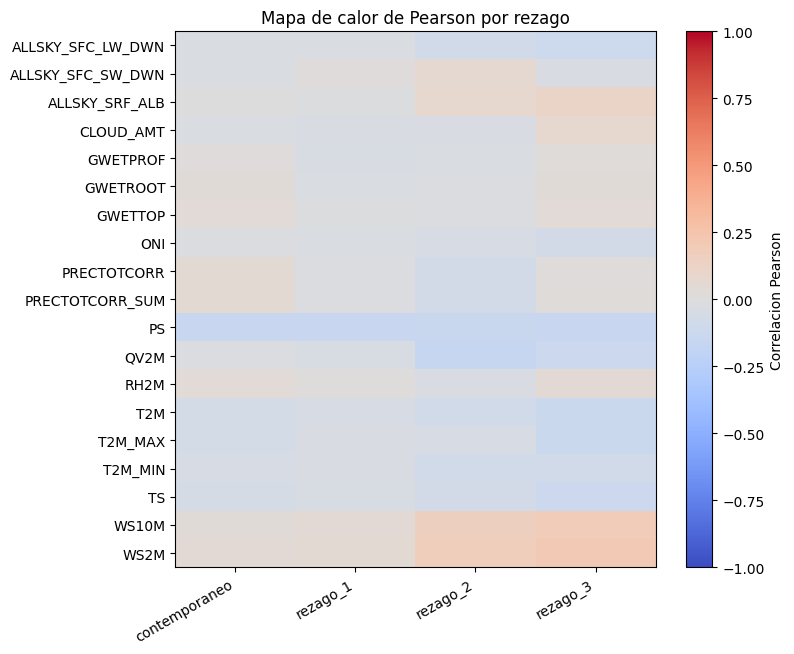

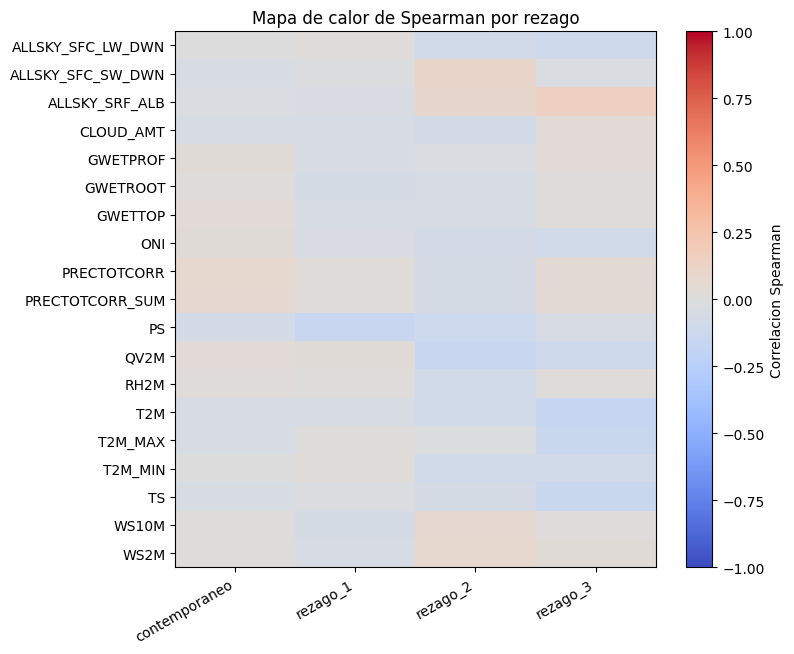

In [8]:
def plot_lag_heatmap(metric_col, title):
    matrix_rows = []
    for variable in climate_columns:
        contemporary_value = contemporary_climate.loc[contemporary_climate["variable"] == variable, f"{metric_col}_contemporaneo"].iloc[0]
        row = {"variable": variable, "contemporaneo": contemporary_value}
        for lag in [1, 2, 3]:
            value = correlaciones_rezagos.loc[
                (correlaciones_rezagos["variable"] == variable) &
                (correlaciones_rezagos["rezago_bimestres"] == lag),
                metric_col
            ].iloc[0]
            row[f"rezago_{lag}"] = value
        matrix_rows.append(row)
    mat_df = pd.DataFrame(matrix_rows).set_index("variable")
    plt.figure(figsize=(8, max(6, len(mat_df) * 0.35)))
    plt.imshow(mat_df.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(label=f"Correlacion {metric_col.capitalize()}")
    plt.xticks(range(mat_df.shape[1]), mat_df.columns, rotation=30, ha="right")
    plt.yticks(range(mat_df.shape[0]), mat_df.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return mat_df


heatmap_pearson = plot_lag_heatmap("pearson", "Mapa de calor de Pearson por rezago")
heatmap_spearman = plot_lag_heatmap("spearman", "Mapa de calor de Spearman por rezago")


## 8. Seleccion de rezagos usando exclusivamente 2020-2023


In [9]:
# Criterio definido antes de evaluar 2024:
# - usar solo correlaciones calculadas con pares objetivo en 2020-2023;
# - n >= 300 pares validos;
# - p ajustado BH de Spearman <= 0.10;
# - |Spearman rezagado| >= 0.30;
# - mejora de |Spearman| frente al contemporaneo >= 0.05;
# - conservar como maximo cinco rezagos para limitar sobreajuste.

lag_corr_2020_2023_rows = []
base_lag_selection = df_raw[df_raw[YEAR_COL].between(2020, 2023)].copy()
lag_corr_2020_2023, lag_features_selection = create_exact_lag_table(base_lag_selection, climate_columns, lags=(1, 2, 3))
contemporary_climate_2020_2023 = corr_2020_2023[corr_2020_2023["variable"].isin(climate_columns)][["variable", "spearman"]].rename(columns={"spearman": "spearman_contemporaneo_2020_2023"})
lag_corr_2020_2023 = lag_corr_2020_2023.merge(contemporary_climate_2020_2023, on="variable", how="left")
lag_corr_2020_2023["mejora_abs_spearman_vs_contemporaneo"] = lag_corr_2020_2023["spearman"].abs() - lag_corr_2020_2023["spearman_contemporaneo_2020_2023"].abs()
lag_corr_2020_2023["cumple_criterio"] = (
    (lag_corr_2020_2023["n_pares_validos"] >= 300) &
    (lag_corr_2020_2023["p_spearman_ajustado_bh"] <= 0.10) &
    (lag_corr_2020_2023["spearman"].abs() >= 0.30) &
    (lag_corr_2020_2023["mejora_abs_spearman_vs_contemporaneo"] >= 0.05)
)

selected_lags = (
    lag_corr_2020_2023[lag_corr_2020_2023["cumple_criterio"]]
    .sort_values(["spearman", "n_pares_validos"], key=lambda s: s.abs() if s.name == "spearman" else s, ascending=[False, False])
    .head(5)
    .copy()
)

if selected_lags.empty:
    variables_rezagadas_seleccionadas = pd.DataFrame([{
        "variable": "",
        "rezago_bimestres": np.nan,
        "nombre_feature_rezagada": "",
        "criterio": "Ningun rezago cumplio simultaneamente n>=300, q Spearman<=0.10, |Spearman|>=0.30 y mejora>=0.05 frente al contemporaneo en 2020-2023.",
        "periodo_seleccion": "2020-2023",
        "usar_en_modelos": False,
    }])
else:
    variables_rezagadas_seleccionadas = selected_lags.copy()
    variables_rezagadas_seleccionadas["nombre_feature_rezagada"] = variables_rezagadas_seleccionadas.apply(
        lambda r: f"lag_{int(r['rezago_bimestres'])}_{r['variable']}", axis=1
    )
    variables_rezagadas_seleccionadas["criterio"] = "Seleccionado con 2020-2023: n>=300, q Spearman<=0.10, |Spearman|>=0.30, mejora>=0.05; maximo cinco rezagos."
    variables_rezagadas_seleccionadas["periodo_seleccion"] = "2020-2023"
    variables_rezagadas_seleccionadas["usar_en_modelos"] = True

variables_rezagadas_seleccionadas.to_csv("variables_rezagadas_seleccionadas_v9.csv", index=False, encoding="utf-8-sig")
display(variables_rezagadas_seleccionadas)


,variable,rezago_bimestres,nombre_feature_rezagada,criterio,periodo_seleccion,usar_en_modelos
0,,NaN,,"Ningun rezago cumplio simultaneamente n>=300, ...",2020-2023,False


## 9. Comparacion de modelos lineales y XGBoost


In [10]:
def fit_evaluate_models(feature_set_name, include_spatial, extra_lag_features=None, common_complete_lag_mask=False):
    model_prefix = "con_latitud_longitud" if include_spatial else "sin_latitud_longitud"
    X, y_log, y_original, meta, _ = build_design_matrix(
        df_raw,
        include_spatial=include_spatial,
        extra_lag_features=extra_lag_features,
        common_complete_lag_mask=common_complete_lag_mask,
    )
    train_mask = meta[YEAR_COL].between(2020, 2022).reset_index(drop=True)
    val_mask = meta[YEAR_COL].eq(2023).reset_index(drop=True)
    test_mask = meta[YEAR_COL].eq(2024).reset_index(drop=True)

    assert meta.loc[train_mask, YEAR_COL].max() < meta.loc[val_mask, YEAR_COL].min()
    assert meta.loc[val_mask, YEAR_COL].max() < meta.loc[test_mask, YEAR_COL].min()
    assert set(meta.loc[train_mask, "_row_id"]).isdisjoint(set(meta.loc[val_mask, "_row_id"]))
    assert set(meta.loc[train_mask, "_row_id"]).isdisjoint(set(meta.loc[test_mask, "_row_id"]))
    assert set(meta.loc[val_mask, "_row_id"]).isdisjoint(set(meta.loc[test_mask, "_row_id"]))

    X_train_raw, X_val_raw, X_test_raw = X.loc[train_mask].copy(), X.loc[val_mask].copy(), X.loc[test_mask].copy()
    y_train, y_val, y_test = y_log.loc[train_mask].copy(), y_log.loc[val_mask].copy(), y_log.loc[test_mask].copy()
    y_original_test = y_original.loc[test_mask].reset_index(drop=True)

    (X_train_i, X_val_i, X_test_i), imputer = impute_fit_train(X_train_raw, X_val_raw, X_test_raw)

    scaler = StandardScaler()
    X_train_s = pd.DataFrame(scaler.fit_transform(X_train_i), columns=X_train_i.columns, index=X_train_i.index)
    X_val_s = pd.DataFrame(scaler.transform(X_val_i), columns=X_val_i.columns, index=X_val_i.index)
    X_test_s = pd.DataFrame(scaler.transform(X_test_i), columns=X_test_i.columns, index=X_test_i.index)

    rows = []
    pred_rows = []

    def add_metric_rows(model_name, estimator, uses_scaled, selected_param):
        train_X = X_train_s if uses_scaled else X_train_i
        val_X = X_val_s if uses_scaled else X_val_i
        test_X = X_test_s if uses_scaled else X_test_i

        for conjunto, X_split, y_split, years in [
            ("entrenamiento_2020_2022", train_X, y_train, [2020, 2021, 2022]),
            ("validacion_2023", val_X, y_val, [2023]),
        ]:
            pred = estimator.predict(X_split)
            rows.append({
                "experimento": feature_set_name,
                "variante_espacial": model_prefix,
                "modelo": model_name,
                "etapa": "seleccion",
                "conjunto": conjunto,
                "anos": year_label(years),
                "n_registros": len(y_split),
                "n_features": X.shape[1],
                "parametro_seleccionado": selected_param,
                **metrics_original_scale(y_split, pred),
            })

    # Regresion lineal sin hiperparametros.
    lin = LinearRegression()
    lin.fit(X_train_s, y_train.values)
    add_metric_rows("Regresion lineal", lin, True, "sin hiperparametros")

    # Ridge: seleccionar alpha exclusivamente con 2023.
    ridge_candidates = []
    for alpha in RIDGE_ALPHA_GRID:
        ridge_tmp = Ridge(alpha=alpha, random_state=RANDOM_STATE)
        ridge_tmp.fit(X_train_s, y_train.values)
        pred_val = ridge_tmp.predict(X_val_s)
        met_val = metrics_original_scale(y_val, pred_val)
        ridge_candidates.append({"alpha": alpha, **met_val})
    ridge_tuning = pd.DataFrame(ridge_candidates).sort_values(["RMSE", "MAE"], ascending=[True, True]).reset_index(drop=True)
    best_alpha = float(ridge_tuning.iloc[0]["alpha"])
    ridge = Ridge(alpha=best_alpha, random_state=RANDOM_STATE)
    ridge.fit(X_train_s, y_train.values)
    add_metric_rows("Ridge", ridge, True, f"alpha={best_alpha}")

    # XGBoost: parametros temporales seleccionados en v8, sin usar 2024.
    xgb_params = XGB_TEMPORAL_PARAMS_WITH_SPATIAL if include_spatial else XGB_TEMPORAL_PARAMS_WITHOUT_SPATIAL
    xgb_model = XGBRegressor(**xgb_params)
    xgb_model.fit(X_train_i, y_train.values, verbose=False)
    add_metric_rows("XGBoost", xgb_model, False, json.dumps({k: v for k, v in xgb_params.items() if k != "n_jobs"}, sort_keys=True))

    # Reentrenamiento final con 2020-2023 y evaluacion unica en 2024.
    final_train_mask = meta[YEAR_COL].between(2020, 2023).reset_index(drop=True)
    final_test_mask = meta[YEAR_COL].eq(2024).reset_index(drop=True)
    X_final_train_raw, X_final_test_raw = X.loc[final_train_mask].copy(), X.loc[final_test_mask].copy()
    y_final_train, y_final_test = y_log.loc[final_train_mask].copy(), y_log.loc[final_test_mask].copy()
    meta_test = meta.loc[final_test_mask].reset_index(drop=True)

    (X_final_train_i, X_final_test_i), final_imputer = impute_fit_train(X_final_train_raw, X_final_test_raw)
    final_scaler = StandardScaler()
    X_final_train_s = pd.DataFrame(final_scaler.fit_transform(X_final_train_i), columns=X_final_train_i.columns, index=X_final_train_i.index)
    X_final_test_s = pd.DataFrame(final_scaler.transform(X_final_test_i), columns=X_final_test_i.columns, index=X_final_test_i.index)

    final_specs = [
        ("Regresion lineal", LinearRegression(), True, "sin hiperparametros"),
        ("Ridge", Ridge(alpha=best_alpha, random_state=RANDOM_STATE), True, f"alpha={best_alpha}"),
        ("XGBoost", XGBRegressor(**xgb_params), False, json.dumps({k: v for k, v in xgb_params.items() if k != "n_jobs"}, sort_keys=True)),
    ]
    for model_name, estimator, uses_scaled, selected_param in final_specs:
        train_X = X_final_train_s if uses_scaled else X_final_train_i
        test_X = X_final_test_s if uses_scaled else X_final_test_i
        estimator.fit(train_X, y_final_train.values)
        for conjunto, X_split, y_split, years in [
            ("entrenamiento_2020_2023", train_X, y_final_train, [2020, 2021, 2022, 2023]),
            ("prueba_2024", test_X, y_final_test, [2024]),
        ]:
            pred = estimator.predict(X_split)
            rows.append({
                "experimento": feature_set_name,
                "variante_espacial": model_prefix,
                "modelo": model_name,
                "etapa": "modelo_final",
                "conjunto": conjunto,
                "anos": year_label(years),
                "n_registros": len(y_split),
                "n_features": X.shape[1],
                "parametro_seleccionado": selected_param,
                **metrics_original_scale(y_split, pred),
            })
            if conjunto == "prueba_2024":
                y_real = np.expm1(y_split.reset_index(drop=True))
                y_pred = np.expm1(pred)
                pred_rows.append(pd.DataFrame({
                    "experimento": feature_set_name,
                    "variante_espacial": model_prefix,
                    "modelo": model_name,
                    "localidad": meta_test[LOCALITY_COL],
                    "ano": meta_test[YEAR_COL].astype(int),
                    "bimestre": meta_test[BIMESTER_COL].astype(int),
                    "valor_real": y_real,
                    "prediccion": y_pred,
                    "error": y_real - y_pred,
                    "error_absoluto": np.abs(y_real - y_pred),
                }))

    return pd.DataFrame(rows), pd.concat(pred_rows, ignore_index=True), ridge_tuning


resultados_modelos = []
predicciones_modelos = []
ridge_tuning_frames = []

for include_spatial in [True, False]:
    metrics_df, preds_df, ridge_tune = fit_evaluate_models(
        "A_contemporaneo",
        include_spatial=include_spatial,
        extra_lag_features=None,
        common_complete_lag_mask=False,
    )
    resultados_modelos.append(metrics_df)
    predicciones_modelos.append(preds_df)
    ridge_tune["experimento"] = "A_contemporaneo"
    ridge_tune["variante_espacial"] = "con_latitud_longitud" if include_spatial else "sin_latitud_longitud"
    ridge_tuning_frames.append(ridge_tune)

selected_feature_names = variables_rezagadas_seleccionadas.loc[
    variables_rezagadas_seleccionadas["usar_en_modelos"].eq(True),
    "nombre_feature_rezagada"
].dropna().tolist()

if selected_feature_names:
    extra_lag_features_model = lag_features_all[["_row_id"] + selected_feature_names].copy()
    for include_spatial in [True, False]:
        metrics_df, preds_df, ridge_tune = fit_evaluate_models(
            "B_contemporaneo_mas_rezagos",
            include_spatial=include_spatial,
            extra_lag_features=extra_lag_features_model,
            common_complete_lag_mask=True,
        )
        resultados_modelos.append(metrics_df)
        predicciones_modelos.append(preds_df)
        ridge_tune["experimento"] = "B_contemporaneo_mas_rezagos"
        ridge_tune["variante_espacial"] = "con_latitud_longitud" if include_spatial else "sin_latitud_longitud"
        ridge_tuning_frames.append(ridge_tune)
else:
    print("No se ejecuta el experimento B como comparacion equivalente porque no se seleccionaron rezagos bajo el criterio definido.")

resultados_modelos_lineales_xgboost = pd.concat(resultados_modelos, ignore_index=True)
predicciones_modelos_2024 = pd.concat(predicciones_modelos, ignore_index=True)
tuning_ridge_v9 = pd.concat(ridge_tuning_frames, ignore_index=True)

resultados_modelos_lineales_xgboost.to_csv("resultados_modelos_lineales_xgboost_v9.csv", index=False, encoding="utf-8-sig")
predicciones_modelos_2024.to_csv("predicciones_modelos_2024_v9.csv", index=False, encoding="utf-8-sig")
tuning_ridge_v9.to_csv("tuning_ridge_v9.csv", index=False, encoding="utf-8-sig")

test_2024_results = resultados_modelos_lineales_xgboost[
    (resultados_modelos_lineales_xgboost["etapa"] == "modelo_final") &
    (resultados_modelos_lineales_xgboost["conjunto"] == "prueba_2024")
].copy()
display(test_2024_results.sort_values(["experimento", "variante_espacial", "RMSE", "MAE"]))


No se ejecuta el experimento B como comparacion equivalente porque no se seleccionaron rezagos bajo el criterio definido.


,experimento,variante_espacial,modelo,etapa,conjunto,anos,n_registros,n_features,parametro_seleccionado,MAE,RMSE,R2
11,A_contemporaneo,con_latitud_longitud,XGBoost,modelo_final,prueba_2024,2024,117,24,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.121197,2.000640,0.293491
9,A_contemporaneo,con_latitud_longitud,Ridge,modelo_final,prueba_2024,2024,117,24,alpha=1000.0,1.785609,2.280750,0.081805
7,A_contemporaneo,con_latitud_longitud,Regresion lineal,modelo_final,prueba_2024,2024,117,24,sin hiperparametros,2.709185,2.982352,-0.569991
21,A_contemporaneo,sin_latitud_longitud,Ridge,modelo_final,prueba_2024,2024,117,22,alpha=1000.0,1.846628,2.384443,-0.003583
23,A_contemporaneo,sin_latitud_longitud,XGBoost,modelo_final,prueba_2024,2024,117,22,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",1.931455,2.443260,-0.053704
19,A_contemporaneo,sin_latitud_longitud,Regresion lineal,modelo_final,prueba_2024,2024,117,22,sin hiperparametros,3.113925,3.410679,-1.053341


,estado,motivo
0,sin_experimento_B,Ningun rezago cumplio el criterio de seleccion...


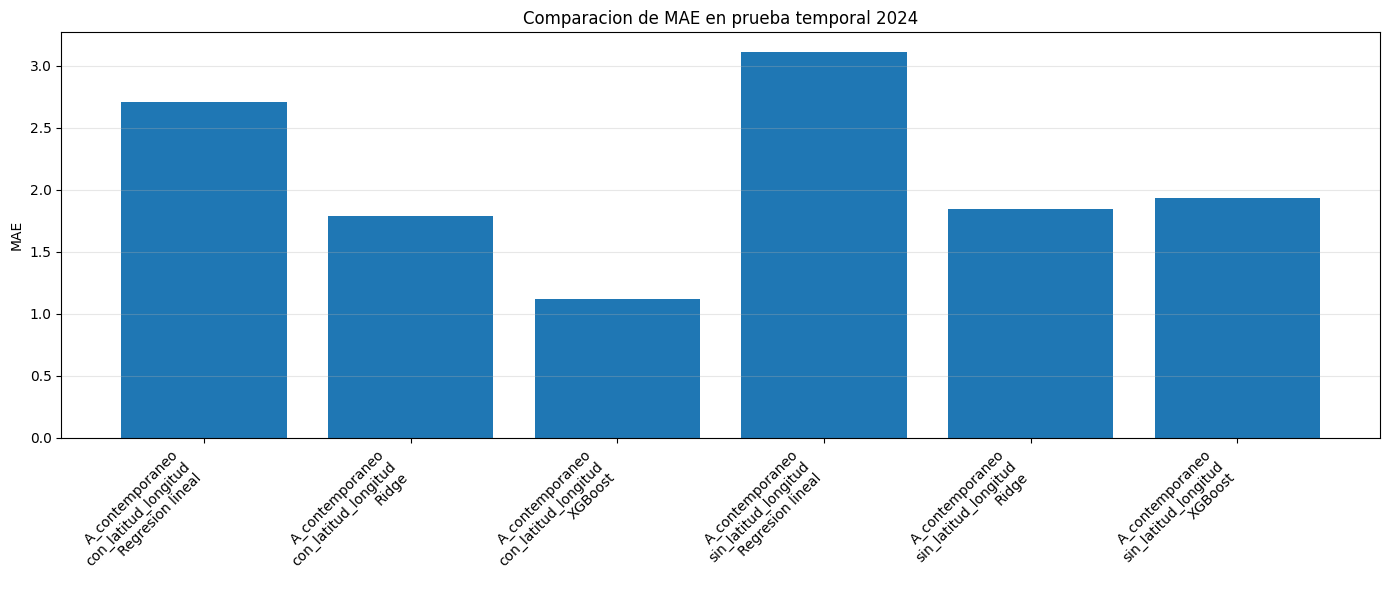

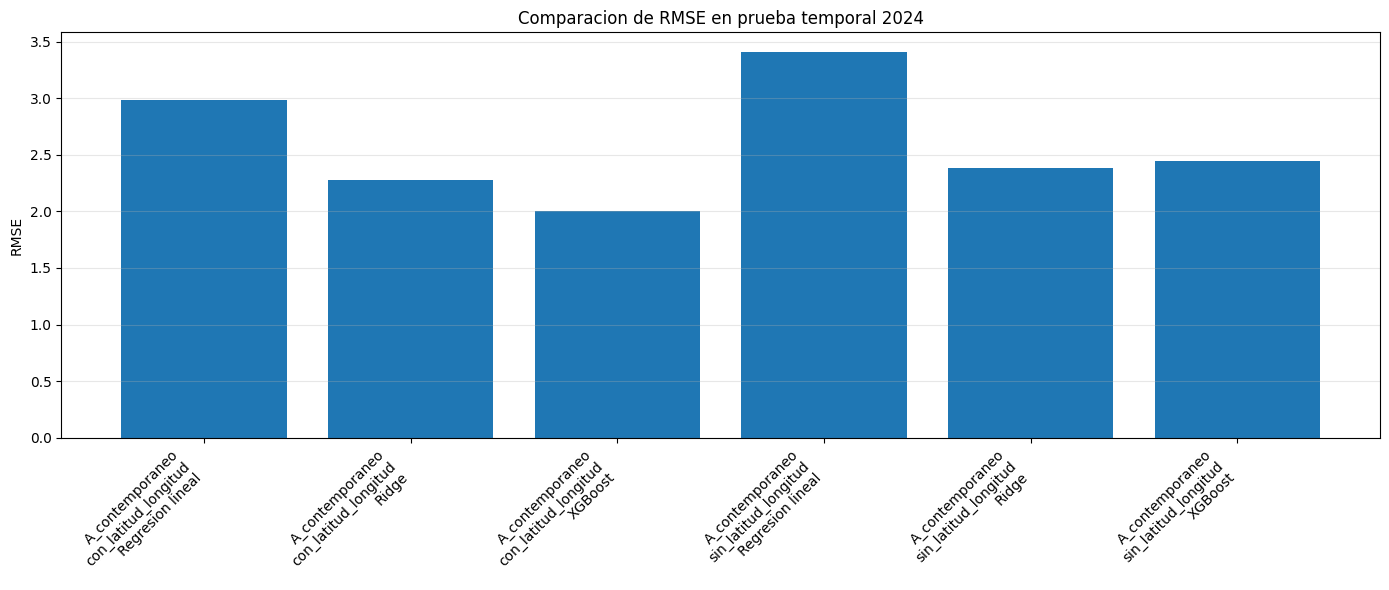

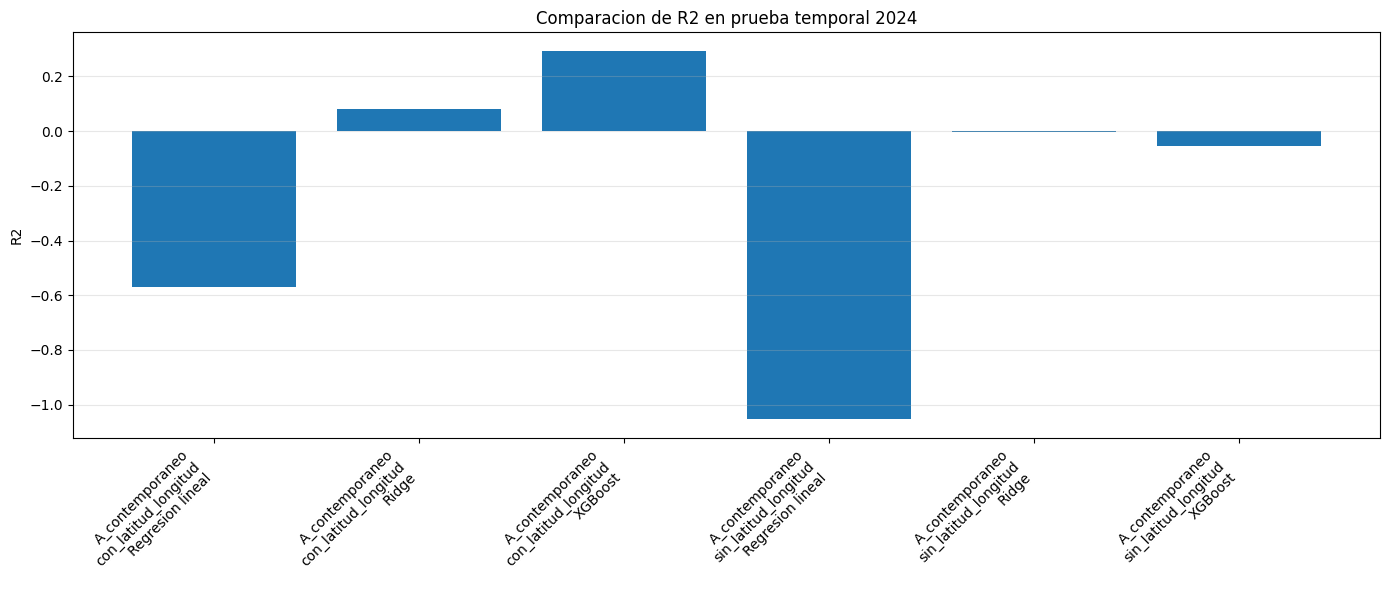

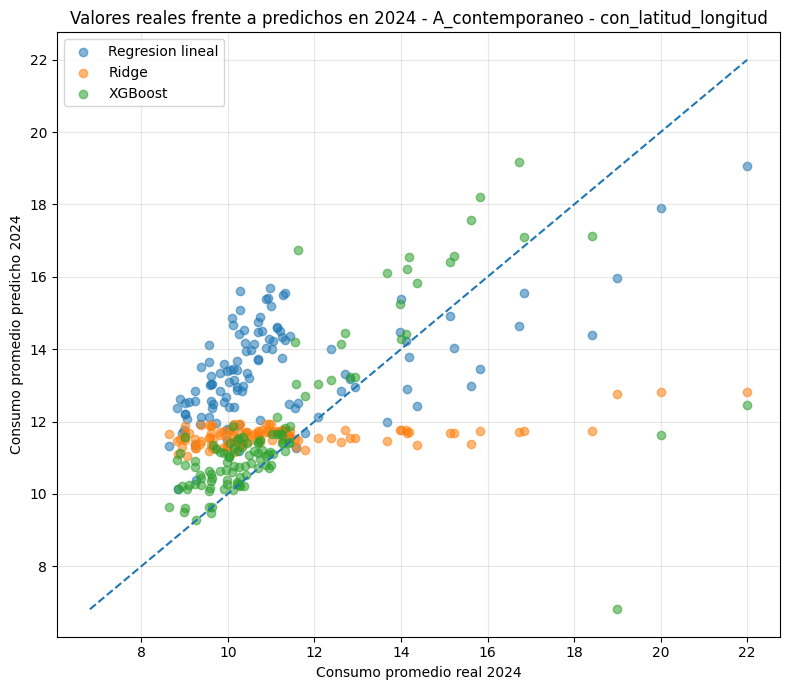

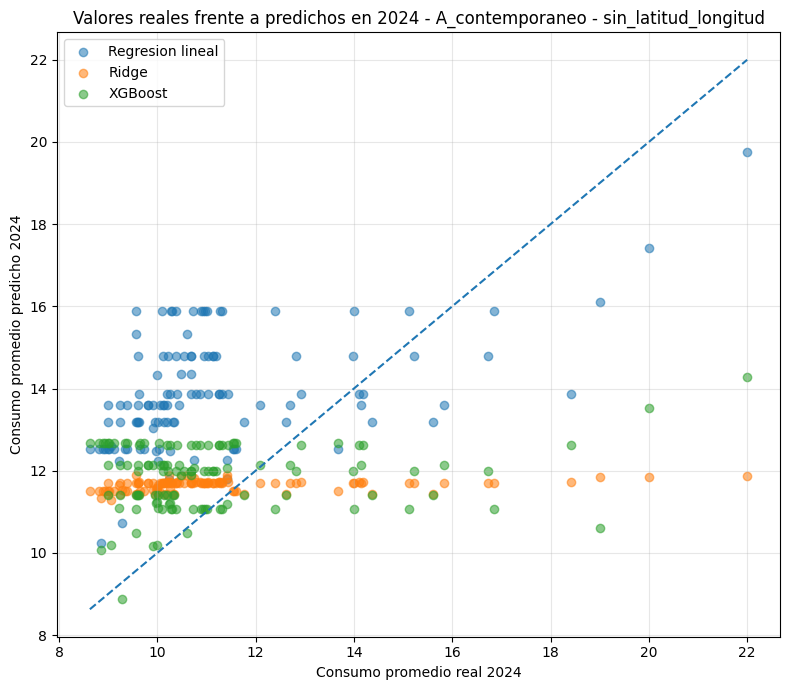

In [11]:
if selected_feature_names:
    comparacion_contemporaneo_rezagos = test_2024_results.pivot_table(
        index=["variante_espacial", "modelo"],
        columns="experimento",
        values=["MAE", "RMSE", "R2"],
        aggfunc="first",
    )
    comparacion_contemporaneo_rezagos.columns = ["_".join(col).strip() for col in comparacion_contemporaneo_rezagos.columns.to_flat_index()]
    comparacion_contemporaneo_rezagos = comparacion_contemporaneo_rezagos.reset_index()
else:
    comparacion_contemporaneo_rezagos = pd.DataFrame([{
        "estado": "sin_experimento_B",
        "motivo": "Ningun rezago cumplio el criterio de seleccion definido con 2020-2023; no se comparan modelos con rezagos sobre bases distintas."
    }])
comparacion_contemporaneo_rezagos.to_csv("comparacion_contemporaneo_rezagos_v9.csv", index=False, encoding="utf-8-sig")
display(comparacion_contemporaneo_rezagos)

for metric in ["MAE", "RMSE", "R2"]:
    plot_df = test_2024_results.copy()
    plot_df["etiqueta"] = plot_df["experimento"] + "\n" + plot_df["variante_espacial"] + "\n" + plot_df["modelo"]
    plt.figure(figsize=(14, 6))
    plt.bar(plot_df["etiqueta"], plot_df[metric])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(f"Comparacion de {metric} en prueba temporal 2024")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

for (experimento, variante), group in predicciones_modelos_2024.groupby(["experimento", "variante_espacial"]):
    plt.figure(figsize=(8, 7))
    for model_name, sub in group.groupby("modelo"):
        plt.scatter(sub["valor_real"], sub["prediccion"], alpha=0.55, label=model_name)
    min_v = min(group["valor_real"].min(), group["prediccion"].min())
    max_v = max(group["valor_real"].max(), group["prediccion"].max())
    plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
    plt.xlabel("Consumo promedio real 2024")
    plt.ylabel("Consumo promedio predicho 2024")
    plt.title(f"Valores reales frente a predichos en 2024 - {experimento} - {variante}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 10. Sintesis academica y texto propuesto para la tesis


In [12]:
def markdown_table(df, columns):
    tmp = df[columns].copy()
    for c in tmp.columns:
        if pd.api.types.is_numeric_dtype(tmp[c]):
            tmp[c] = tmp[c].map(lambda x: f"{x:.4f}")
    header = "| " + " | ".join(columns) + " |"
    sep = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(str(v) for v in row) + " |" for row in tmp.to_numpy()]
    return "\n".join([header, sep] + body)

top_spearman = corr_all.head(5)[["variable", "pearson", "spearman", "magnitud_spearman", "spearman_supera_pearson"]]
top_mi_final = informacion_mutua.head(5)[["variable", "informacion_mutua_media", "informacion_mutua_std", "ranking_mi", "pearson", "spearman"]]
top_lags = correlaciones_rezagos.sort_values("spearman", key=lambda s: s.abs(), ascending=False).head(5)[
    ["variable", "rezago_bimestres", "n_pares_validos", "pearson", "spearman", "p_spearman_ajustado_bh", "cambio_abs_spearman_vs_contemporaneo"]
]
model_test = test_2024_results.sort_values(["experimento", "variante_espacial", "RMSE", "MAE"])[
    ["experimento", "variante_espacial", "modelo", "MAE", "RMSE", "R2"]
]

xgb_con = model_test[
    (model_test["experimento"] == "A_contemporaneo") &
    (model_test["variante_espacial"] == "con_latitud_longitud") &
    (model_test["modelo"] == "XGBoost")
].iloc[0]
lin_con = model_test[
    (model_test["experimento"] == "A_contemporaneo") &
    (model_test["variante_espacial"] == "con_latitud_longitud") &
    (model_test["modelo"] == "Regresion lineal")
].iloc[0]
ridge_con = model_test[
    (model_test["experimento"] == "A_contemporaneo") &
    (model_test["variante_espacial"] == "con_latitud_longitud") &
    (model_test["modelo"] == "Ridge")
].iloc[0]

if xgb_con["RMSE"] < min(lin_con["RMSE"], ridge_con["RMSE"]):
    conclusion_modelos = "XGBoost presento menor RMSE que los modelos lineales bajo la prueba temporal 2024 con coordenadas."
elif min(lin_con["RMSE"], ridge_con["RMSE"]) <= xgb_con["RMSE"]:
    conclusion_modelos = "Los modelos lineales igualaron o superaron a XGBoost en RMSE bajo la prueba temporal 2024 con coordenadas."
else:
    conclusion_modelos = "Las diferencias entre modelos no permiten afirmar una superioridad concluyente."

selected_text = (
    ", ".join(selected_feature_names)
    if selected_feature_names
    else "ningun rezago cumplio el criterio definido con 2020-2023"
)

texto = f'''
### Sintesis de resultados v9

El analisis contemporaneo de Pearson y Spearman muestra que las asociaciones deben interpretarse con prudencia. La clasificacion usada es descriptiva: menor de 0,10 corresponde a asociacion muy debil; entre 0,10 y 0,29, debil; entre 0,30 y 0,49, moderada; e igual o superior a 0,50, alta. Esta clasificacion no implica causalidad. Las variables con mayor |Spearman| en los 596 registros fueron:

{markdown_table(top_spearman, ["variable", "pearson", "spearman", "magnitud_spearman", "spearman_supera_pearson"])}

La informacion mutua fue estimada con datos 2020-2023, imputacion ajustada solo con ese periodo, `random_state=42`, `n_neighbors=3` y 50 remuestreos bootstrap. Sus valores no son pruebas de significancia ni indican direccion del efecto; solo sugieren dependencia estadistica potencial. Las mayores puntuaciones fueron:

{markdown_table(top_mi_final, ["variable", "informacion_mutua_media", "informacion_mutua_std", "ranking_mi", "pearson", "spearman"])}

Los rezagos se construyeron mediante `indice_tiempo=(ano-2020)*6+(BIMESTRE-1)` y union exacta por localidad e indice temporal. Esto evita que periodos ausentes, como algunos registros de Sumapaz, sean conectados mediante un simple `shift`. Los principales coeficientes rezagados observados fueron:

{markdown_table(top_lags, ["variable", "rezago_bimestres", "n_pares_validos", "pearson", "spearman", "p_spearman_ajustado_bh", "cambio_abs_spearman_vs_contemporaneo"])}

Para la construccion de modelos con rezagos se definio antes de evaluar 2024 el siguiente criterio: usar solo 2020-2023, exigir al menos 300 pares validos, q de Spearman <= 0,10, |Spearman| >= 0,30 y mejora de |Spearman| frente al contemporaneo >= 0,05, conservando maximo cinco rezagos. Bajo este criterio, el resultado fue: {selected_text}.

La comparacion temporal de modelos sobre 2024 fue:

{markdown_table(model_test, ["experimento", "variante_espacial", "modelo", "MAE", "RMSE", "R2"])}

{conclusion_modelos} Esta evidencia permite comparar empiricamente modelos lineales y no lineales bajo la misma division temporal, pero no autoriza afirmar que se haya demostrado causalidad ni que las relaciones sean necesariamente no lineales. La formulacion mas defendible es que el desempeno relativo de XGBoost y de los modelos lineales depende de la validacion temporal y del conjunto de variables usado.

Texto propuesto para analisis exploratorio: "La evaluacion exploratoria no se limito a correlaciones de Pearson. Se calcularon correlaciones de Spearman y se aplico correccion de Benjamini-Hochberg para controlar comparaciones multiples. Esta etapa permitio diferenciar asociaciones lineales de asociaciones monotonicas y evitar descartar modelos lineales unicamente por correlaciones Pearson bajas."

Texto propuesto para identificacion de variables: "La informacion mutua se uso como medida complementaria de dependencia estadistica potencial entre predictores y consumo promedio. Sus resultados fueron interpretados como evidencia descriptiva de asociacion, sin direccion, signo ni inferencia causal."

Texto propuesto para justificacion de modelos: "La eleccion de modelos no lineales no se fundamento exclusivamente en correlaciones bivariadas. Se compararon regresion lineal multiple, Ridge y XGBoost bajo la misma particion temporal 2020-2022, 2023 y 2024, entrenando todos los modelos sobre log1p(consumo_promedio) y evaluando en la escala original."

Texto propuesto para diseno de modelos: "Ridge selecciono su parametro de regularizacion usando 2023, mientras que XGBoost reutilizo la configuracion temporal seleccionada en v8. Ninguna decision de seleccion utilizo registros de 2024."

Texto propuesto para validacion: "La evaluacion final se realizo sobre 2024 y las metricas MAE, RMSE y R2 se reportaron exclusivamente en la escala original. Las comparaciones entre modelos se hicieron con las mismas filas dentro de cada experimento."

Texto propuesto para discusion: "Los rezagos climaticos se construyeron mediante un indice temporal exacto por localidad, evitando unir bimestres no consecutivos. Cuando los rezagos no cumplieron criterios simultaneos de magnitud, significancia ajustada, estabilidad y tamano de muestra, no se incorporaron al modelo final."

Texto propuesto para limitaciones: "Las asociaciones reportadas son descriptivas y no causales. La informacion mutua no constituye prueba de significancia y los rezagos pueden reflejar patrones temporales espurios si no se validan bajo criterios estrictos."

Texto propuesto para conclusiones: "El experimento v9 permite responder que los modelos lineales no deben descartarse por correlaciones Pearson bajas. La seleccion de enfoques lineales o no lineales debe apoyarse en comparaciones predictivas bajo validaciones temporales consistentes y en analisis complementarios como Spearman, informacion mutua y rezagos construidos correctamente."
'''

display(Markdown(texto))



### Sintesis de resultados v9

El analisis contemporaneo de Pearson y Spearman muestra que las asociaciones deben interpretarse con prudencia. La clasificacion usada es descriptiva: menor de 0,10 corresponde a asociacion muy debil; entre 0,10 y 0,29, debil; entre 0,30 y 0,49, moderada; e igual o superior a 0,50, alta. Esta clasificacion no implica causalidad. Las variables con mayor |Spearman| en los 596 registros fueron:

| variable | pearson | spearman | magnitud_spearman | spearman_supera_pearson |
| --- | --- | --- | --- | --- |
| BIMESTRE_sin | 0.1299 | 0.1674 | debil | 0.0000 |
| latitud | -0.4152 | -0.1017 | debil | 0.0000 |
| PRECTOTCORR | 0.0503 | 0.0707 | muy debil | 0.0000 |
| PS | -0.1462 | -0.0687 | muy debil | 0.0000 |
| año | -0.0692 | -0.0677 | muy debil | 0.0000 |

La informacion mutua fue estimada con datos 2020-2023, imputacion ajustada solo con ese periodo, `random_state=42`, `n_neighbors=3` y 50 remuestreos bootstrap. Sus valores no son pruebas de significancia ni indican direccion del efecto; solo sugieren dependencia estadistica potencial. Las mayores puntuaciones fueron:

| variable | informacion_mutua_media | informacion_mutua_std | ranking_mi | pearson | spearman |
| --- | --- | --- | --- | --- | --- |
| longitud | 1.4075 | 0.0816 | 1.0000 | -0.1702 | 0.0855 |
| latitud | 1.3455 | 0.0781 | 2.0000 | -0.3976 | -0.1078 |
| PS | 0.6372 | 0.0741 | 3.0000 | -0.1358 | -0.0422 |
| T2M | 0.5887 | 0.0910 | 4.0000 | -0.0592 | -0.0243 |
| TS | 0.5875 | 0.0818 | 5.0000 | -0.0580 | -0.0390 |

Los rezagos se construyeron mediante `indice_tiempo=(ano-2020)*6+(BIMESTRE-1)` y union exacta por localidad e indice temporal. Esto evita que periodos ausentes, como algunos registros de Sumapaz, sean conectados mediante un simple `shift`. Los principales coeficientes rezagados observados fueron:

| variable | rezago_bimestres | n_pares_validos | pearson | spearman | p_spearman_ajustado_bh | cambio_abs_spearman_vs_contemporaneo |
| --- | --- | --- | --- | --- | --- | --- |
| T2M | 3.0000 | 535.0000 | -0.1271 | -0.1504 | 0.0098 | 0.0977 |
| QV2M | 2.0000 | 555.0000 | -0.1561 | -0.1470 | 0.0098 | 0.1086 |
| ALLSKY_SRF_ALB | 3.0000 | 535.0000 | 0.1094 | 0.1463 | 0.0098 | 0.1229 |
| PS | 1.0000 | 575.0000 | -0.1407 | -0.1421 | 0.0098 | 0.0734 |
| TS | 3.0000 | 535.0000 | -0.1247 | -0.1344 | 0.0182 | 0.0908 |

Para la construccion de modelos con rezagos se definio antes de evaluar 2024 el siguiente criterio: usar solo 2020-2023, exigir al menos 300 pares validos, q de Spearman <= 0,10, |Spearman| >= 0,30 y mejora de |Spearman| frente al contemporaneo >= 0,05, conservando maximo cinco rezagos. Bajo este criterio, el resultado fue: ningun rezago cumplio el criterio definido con 2020-2023.

La comparacion temporal de modelos sobre 2024 fue:

| experimento | variante_espacial | modelo | MAE | RMSE | R2 |
| --- | --- | --- | --- | --- | --- |
| A_contemporaneo | con_latitud_longitud | XGBoost | 1.1212 | 2.0006 | 0.2935 |
| A_contemporaneo | con_latitud_longitud | Ridge | 1.7856 | 2.2808 | 0.0818 |
| A_contemporaneo | con_latitud_longitud | Regresion lineal | 2.7092 | 2.9824 | -0.5700 |
| A_contemporaneo | sin_latitud_longitud | Ridge | 1.8466 | 2.3844 | -0.0036 |
| A_contemporaneo | sin_latitud_longitud | XGBoost | 1.9315 | 2.4433 | -0.0537 |
| A_contemporaneo | sin_latitud_longitud | Regresion lineal | 3.1139 | 3.4107 | -1.0533 |

XGBoost presento menor RMSE que los modelos lineales bajo la prueba temporal 2024 con coordenadas. Esta evidencia permite comparar empiricamente modelos lineales y no lineales bajo la misma division temporal, pero no autoriza afirmar que se haya demostrado causalidad ni que las relaciones sean necesariamente no lineales. La formulacion mas defendible es que el desempeno relativo de XGBoost y de los modelos lineales depende de la validacion temporal y del conjunto de variables usado.

Texto propuesto para analisis exploratorio: "La evaluacion exploratoria no se limito a correlaciones de Pearson. Se calcularon correlaciones de Spearman y se aplico correccion de Benjamini-Hochberg para controlar comparaciones multiples. Esta etapa permitio diferenciar asociaciones lineales de asociaciones monotonicas y evitar descartar modelos lineales unicamente por correlaciones Pearson bajas."

Texto propuesto para identificacion de variables: "La informacion mutua se uso como medida complementaria de dependencia estadistica potencial entre predictores y consumo promedio. Sus resultados fueron interpretados como evidencia descriptiva de asociacion, sin direccion, signo ni inferencia causal."

Texto propuesto para justificacion de modelos: "La eleccion de modelos no lineales no se fundamento exclusivamente en correlaciones bivariadas. Se compararon regresion lineal multiple, Ridge y XGBoost bajo la misma particion temporal 2020-2022, 2023 y 2024, entrenando todos los modelos sobre log1p(consumo_promedio) y evaluando en la escala original."

Texto propuesto para diseno de modelos: "Ridge selecciono su parametro de regularizacion usando 2023, mientras que XGBoost reutilizo la configuracion temporal seleccionada en v8. Ninguna decision de seleccion utilizo registros de 2024."

Texto propuesto para validacion: "La evaluacion final se realizo sobre 2024 y las metricas MAE, RMSE y R2 se reportaron exclusivamente en la escala original. Las comparaciones entre modelos se hicieron con las mismas filas dentro de cada experimento."

Texto propuesto para discusion: "Los rezagos climaticos se construyeron mediante un indice temporal exacto por localidad, evitando unir bimestres no consecutivos. Cuando los rezagos no cumplieron criterios simultaneos de magnitud, significancia ajustada, estabilidad y tamano de muestra, no se incorporaron al modelo final."

Texto propuesto para limitaciones: "Las asociaciones reportadas son descriptivas y no causales. La informacion mutua no constituye prueba de significancia y los rezagos pueden reflejar patrones temporales espurios si no se validan bajo criterios estrictos."

Texto propuesto para conclusiones: "El experimento v9 permite responder que los modelos lineales no deben descartarse por correlaciones Pearson bajas. La seleccion de enfoques lineales o no lineales debe apoyarse en comparaciones predictivas bajo validaciones temporales consistentes y en analisis complementarios como Spearman, informacion mutua y rezagos construidos correctamente."


## 11. Verificacion final


In [13]:
required_csvs = [
    "correlaciones_pearson_spearman_v9.csv",
    "informacion_mutua_v9.csv",
    "correlaciones_rezagos_v9.csv",
    "resumen_rezagos_v9.csv",
    "variables_rezagadas_seleccionadas_v9.csv",
    "resultados_modelos_lineales_xgboost_v9.csv",
    "predicciones_modelos_2024_v9.csv",
    "comparacion_contemporaneo_rezagos_v9.csv",
]
print("Archivos requeridos:")
for path in required_csvs:
    print(" -", path, "OK" if Path(path).exists() else "NO")
    assert Path(path).exists()

assert set(predicciones_modelos_2024["ano"].unique()) == {2024}
assert resultados_modelos_lineales_xgboost["MAE"].notna().all()
assert resultados_modelos_lineales_xgboost["RMSE"].notna().all()
assert resultados_modelos_lineales_xgboost["R2"].notna().all()

# Verificar que los modelos comparados usan las mismas filas dentro de cada experimento y variante.
for (experimento, variante), group in predicciones_modelos_2024.groupby(["experimento", "variante_espacial"]):
    sets = group.groupby("modelo").apply(lambda d: set(zip(d["localidad"], d["ano"], d["bimestre"])))
    first = sets.iloc[0]
    assert all(s == first for s in sets), f"Filas no equivalentes en {experimento}, {variante}"

# Verificar que no hubo seleccion con 2024.
assert variables_rezagadas_seleccionadas["periodo_seleccion"].eq("2020-2023").all()

# Verificar hashes de notebooks anteriores.
expected_hashes = {
    "predic_consumo_agua.ipynb": "1ADF3CC3EEB35F15256C4EA58C3CF0FF4048BB97D655735B34F9FD39263E38EB",
    "predic_consumo_agua_v2.ipynb": "18CBC8F73BB1ACE3DBC391FDA5F3E1BD373459F4F5AC48F662E034FE40DFDB60",
    "predic_consumo_agua_v3.ipynb": "52F9F75781D6714CB8841E84958C639CD3DACC4DFB649092D8E94FBF16385F0D",
    "predic_consumo_agua_v4.ipynb": "EDA0A1F25A0F4934E66FDB85D85134CAD0C46119E07F20F4741C6D7E14E7A31E",
    "predic_consumo_agua_v5.ipynb": "C5BEAAFA7590CE114F8B5BC4913F1B69A0819CC78009212E4D77FDFAEB044890",
    "predic_consumo_agua_v6.ipynb": "2E52F31545F6E2EBB27E7430FD20A0A4838862AF1353970E2AF4503D80054E7C",
    "predic_consumo_agua_v7.ipynb": "7793E98532CE6EB4E74D98BD648707D2B422FE1B2F7988D447D2863A2FC89932",
    "predic_consumo_agua_v8.ipynb": "A7394F0374DD3078A3A849C9E64652BDC33E4633403004047CC9F7ACC4AAE4DF",
}
for filename, expected in expected_hashes.items():
    actual = hashlib.sha256(Path(filename).read_bytes()).hexdigest().upper()
    assert actual == expected, f"Hash modificado para {filename}"

print("\nVerificaciones finales superadas:")
print(" - Todas las celdas previas se ejecutaron sin errores.")
print(" - Metricas en escala original mediante expm1.")
print(" - 2024 no se uso para seleccion de rezagos, Ridge ni XGBoost.")
print(" - Rezagos retrospectivos por union exacta localidad-indice temporal.")
print(" - Modelos comparados con las mismas filas dentro de cada experimento.")
print(" - Notebooks v1-v8 permanecen sin modificaciones.")


Archivos requeridos:
 - correlaciones_pearson_spearman_v9.csv OK
 - informacion_mutua_v9.csv OK
 - correlaciones_rezagos_v9.csv OK
 - resumen_rezagos_v9.csv OK
 - variables_rezagadas_seleccionadas_v9.csv OK
 - resultados_modelos_lineales_xgboost_v9.csv OK
 - predicciones_modelos_2024_v9.csv OK
 - comparacion_contemporaneo_rezagos_v9.csv OK

Verificaciones finales superadas:
 - Todas las celdas previas se ejecutaron sin errores.
 - Metricas en escala original mediante expm1.
 - 2024 no se uso para seleccion de rezagos, Ridge ni XGBoost.
 - Rezagos retrospectivos por union exacta localidad-indice temporal.
 - Modelos comparados con las mismas filas dentro de cada experimento.
 - Notebooks v1-v8 permanecen sin modificaciones.
